# Data Preprocessing
## Objective
Prepare the dataset for machine learning by :
- Encoding categorical variables
- Splitting features and target
- Scaling numerical variables

In [70]:
from statistics import linear_regression

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
# Load data
df = pd.read_csv("C:\\Users\\PC\\PycharmProjects\\PythonProject1\\data\\raw data\\insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Seperate Features and Target
## Define x and y


In [17]:
X = df.drop('charges', axis=1)
y = df['charges']

# Encode Categorical Variables
## Sex, Region, smoker

In [18]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


# Train_Test Split
## Split Data
This helps the model learn, become evaluated and avoid overfitting

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) # Allocating 20% of the to test (o.2)


# Feature Scaling
Important for:
- Linear Regression
- Gradient-based models
## Scale Numerical Features

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Linear Regression Model

In [53]:
lr = LinearRegression()

# Train
lr.fit(X_train_scaled, y_train)

# Predict
lr_predict = lr.predict(X_test_scaled)

# Evaluate
lr_mae = mean_absolute_error(y_test, lr_predict)
lr_mse = mean_squared_error(y_test, lr_predict)
lr_r2 = r2_score(y_test, lr_predict)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("R2:", lr_r2)

Linear Regression Results
MAE: 4181.194473753652
MSE: 33596915.85136148
R2: 0.7835929767120722


# Decision Tree Model - No Scaling


In [59]:
# Train model
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# Predict
dt_pred = dt.predict(X_test)

# Evaluate
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regression Results")
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("R2:", dt_r2)


Decision Tree Regression Results
MAE: 3114.1529092761198
MSE: 40795333.45408598
R2: 0.7372259788399772


# Compare Models


In [75]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'MAE': [lr_mae, dt_mae],
    'MSE': [lr_mse, dt_mse],
    'R2 Score': [lr_r2, dt_r2]
})
results.to_csv('../outputs/tables/model_comparison.csv', index=False)
results


,Model,MAE,MSE,R2 Score
0,Linear Regression,4181.194474,3.359692e+07,0.783593
1,Decision Tree,3114.152909,4.079533e+07,0.737226


# Check Overfit for Decision Tree Model


In [57]:
train_r2 = dt.score(X_train, y_train)
test_r2 = dt.score(X_test, y_test)

print("Decision Tree Train R2:", train_r2)
print("Decision Tree Test R2:", test_r2)

Decision Tree Train R2: 0.9983078124756305
Decision Tree Test R2: 0.7372259788399772


## Model Performance Interpretation

Two models were evaluated for predicting medical insurance charges: **Linear Regression** and **Decision Tree Regressor**.

### Overall Performance

- **Linear Regression**
  - MAE: 4181
  - MSE: 33,596,916
  - R²: 0.784

- **Decision Tree**
  - MAE: 3114
  - MSE: 40,795,333
  - R²: 0.737

### Key Insights

- The **Decision Tree model achieved a lower MAE**, meaning its predictions are closer to the actual values on average.
- However, **Linear Regression has a higher R² score**, indicating it explains more variance in the target variable.
- The **Decision Tree has a higher MSE**, suggesting it makes larger errors in some cases.

###  Overfitting Check (Decision Tree)

- Training R²: 0.998
- Testing R²: 0.737

This large gap indicates that the Decision Tree is **severely overfitting**:
- It memorizes the training data almost perfectly
- But fails to generalize well to unseen data

###  Model Comparison

- **Linear Regression**
  - More stable and generalizes better
  - Slightly higher average error (MAE)

- **Decision Tree**
  - Better at capturing complex patterns
  - Suffers from overfitting, reducing reliability

###  Conclusion

Although the Decision Tree achieves lower MAE, **Linear Regression is the preferred model** due to:
- Better generalization (higher test R²)
- Lower risk of overfitting
- More consistent performance

###  Next Steps

To improve performance further:
- Apply **hyperparameter tuning** to the Decision Tree
- Try **ensemble methods** such as Random Forest or Gradient Boosting
- Perform **feature engineering** to enhance predictive power

# Fix Decision Tree (Control Overfitting)
## Add Hyperparameter Tuning


In [60]:
# Tuned Decision Tree
dt_tuned = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train
dt_tuned.fit(X_train, y_train)

# Predict
dt_tuned_pred = dt_tuned.predict(X_test)

# Evaluate
dt_tuned_mae = mean_absolute_error(y_test, dt_tuned_pred)
dt_tuned_mse = mean_squared_error(y_test, dt_tuned_pred)
dt_tuned_r2 = r2_score(y_test, dt_tuned_pred)

print("Tuned Decision Tree Results")
print("MAE:", dt_tuned_mae)
print("MSE:", dt_tuned_mse)
print("R2:", dt_tuned_r2)

Tuned Decision Tree Results
MAE: 2666.82396474882
MSE: 20332883.75794027
R2: 0.8690302744340446


# Check Overfitting Again

In [61]:
train_r2_tuned = dt_tuned.score(X_train, y_train)
test_r2_tuned = dt_tuned.score(X_test, y_test)

print("Tuned Tree Train R2:", train_r2_tuned)
print("Tuned Tree Test R2:", test_r2_tuned)

Tuned Tree Train R2: 0.8765569489550361
Tuned Tree Test R2: 0.8690302744340446


# Add Random Forest

In [64]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R2:", rf_r2)

Random Forest Results
MAE: 2560.400553561824
MSE: 19640780.629592333
R2: 0.8734883020243351


# Compare ALL Models

In [76]:
results_updated = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Tuned Tree', 'Random Forest'],
    'MAE': [lr_mae, dt_mae, dt_tuned_mae, rf_mae],
    'MSE': [lr_mse, dt_mse, dt_tuned_mse, rf_mse],
    'R2 Score': [lr_r2, dt_r2, dt_tuned_r2, rf_r2]
})
results_updated.sort_values(by='R2 Score', ascending=False).to_csv('../outputs/tables/model_comparison_updated.csv', index=False)
results_updated.sort_values(by='R2 Score', ascending=False)

,Model,MAE,MSE,R2 Score
3,Random Forest,2560.400554,1.964078e+07,0.873488
2,Tuned Tree,2666.823965,2.033288e+07,0.869030
0,Linear Regression,4181.194474,3.359692e+07,0.783593
1,Decision Tree,3114.152909,4.079533e+07,0.737226


# Feature Importance

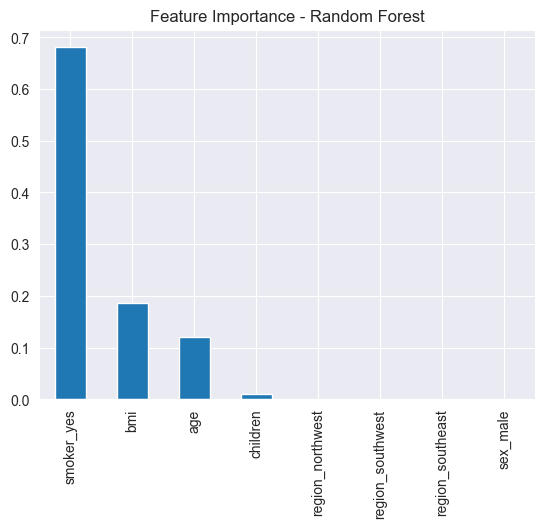

In [77]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
feature_importance.to_csv('../outputs/tables/feature_importance.csv', header=['Importance'])
feature_importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.savefig('../outputs/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Improvement and Final Evaluation

After building the initial models, it was clear that the Decision Tree was overfitting the data. To address this, I applied hyperparameter tuning and introduced a more robust ensemble model (Random Forest).

---

### Tuned Decision Tree

- MAE: 2667
- MSE: 20,332,884
- R²: 0.869

After tuning, the Decision Tree improved significantly:
- The R² increased from **0.737 to 0.869**, showing a much better fit
- Prediction errors (MSE) were reduced
- The model became more stable overall

To confirm this, I compared training and testing performance:

- Training R²: 0.877
- Testing R²: 0.869

These values are very close, which indicates that the model is **no longer overfitting** and can generalize well to new data.

---

###  Random Forest

- MAE: 2560
- MSE: 19,640,781
- R²: 0.873

The Random Forest model performed the best across all metrics:
- It achieved the **lowest prediction error (MAE and MSE)**
- It also had the **highest R²**, meaning it explains the most variation in medical charges

This improvement is expected because Random Forest combines multiple decision trees, reducing the risk of overfitting and improving overall accuracy.

---

###  Model Comparison

- **Linear Regression**
  - Simple and stable
  - Performs well but cannot capture complex relationships

- **Decision Tree (Untuned)**
  - Captures patterns but heavily overfits

- **Tuned Decision Tree**
  - Much better balance between learning and generalization
  - Strong improvement after controlling model complexity

- **Random Forest**
  - Best overall performance
  - Most reliable and accurate model

---

###  Final Model Choice

The **Random Forest model** is selected as the final model because it provides:
- The highest accuracy (R² = 0.873)
- The lowest prediction errors
- Strong generalization to unseen data

---

###  Key Takeaway

This analysis shows that:
- Medical insurance charges are influenced by **complex, non-linear relationships**
- Simple models like Linear Regression may miss these patterns
- Tree-based models, especially ensemble methods, are better suited for this type of problem

---

###  What’s Next

To further strengthen this analysis:
- Examine **feature importance** to understand key drivers of cost
- Apply **cross-validation** for more robust evaluation
- Experiment with more advanced models like Gradient Boosting

# Residual Analysis
## Check if the model's errors are random(good) or patterned(bad)

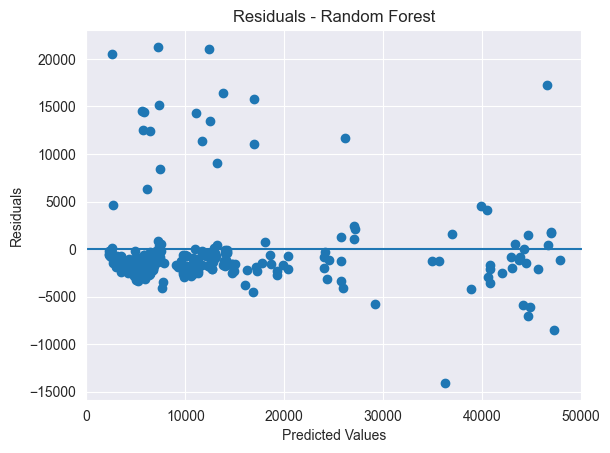

In [73]:
# Residuals using the random forest model (best)
residuals = y_test -rf_pred
plt.scatter(rf_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals - Random Forest")
plt.savefig('../outputs/figures/residuals_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

# Cross-Validation
- This shows the model is not lucky on one split

In [71]:
rf_cv_scores = cross_val_score(
    rf, X, y,
    cv=5,
    scoring='r2'
)

print("Cross-Validation R2 Scores:", rf_cv_scores)
print("Mean CV R2:", rf_cv_scores.mean())

Cross-Validation R2 Scores: [0.88189116 0.80105153 0.89102719 0.84221465 0.86973237]
Mean CV R2: 0.8571833794699522
